##Linear Regression on California Housing Dataset

To implement Simple Linear Regression using a single feature from the California Housing dataset to predict house prices using:

Gradient Descent
Normal Equation

Evaluate the model using:

Mean Squared Error (MSE)
R² Score

Visualize the regression line.

#Import Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries Imported")

Libraries Imported


## Load the California Housing Dataset

The California Housing dataset contains information such as:

- Median Income
- House Age
- Average Rooms
- Average Bedrooms
- Population
- Average Occupancy
- Latitude
- Longitude

For this experiment, we use **Average Number of Rooms (AveRooms)** as the independent variable.

In [4]:
housing = fetch_california_housing()

# Feature: Average Rooms
X = housing.data[:, 2]

# Target: Median House Value
y = housing.target

X = X.reshape(-1, 1)

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (20640, 1)
Target Shape: (20640,)


## Split the Dataset

Split the dataset into training and testing sets.

- Training Data : 80%
- Testing Data : 20%

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 16512
Testing Samples : 4128


## Feature Scaling

Gradient Descent converges faster when the feature is standardized.

In [8]:
mean = X_train.mean()
std = X_train.std()

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

X_train_scaled = X_train_scaled.flatten()
X_test_scaled = X_test_scaled.flatten()

print("Feature Scaling Done")

Feature Scaling Done


## Linear Regression using Gradient Descent

Initialize the model parameters and update them iteratively.

In [9]:
m = len(X_train_scaled)

theta0 = 0
theta1 = 0

learning_rate = 0.01
epochs = 1000

for epoch in range(epochs):

    predictions = theta0 + theta1 * X_train_scaled

    error = predictions - y_train

    d_theta0 = (1/m) * np.sum(error)
    d_theta1 = (1/m) * np.sum(error * X_train_scaled.flatten())

    theta0 -= learning_rate * d_theta0
    theta1 -= learning_rate * d_theta1

print("Theta0:", theta0)
print("Theta1:", theta1)

Theta0: 2.071857488845021
Theta1: 0.18323090648660517


In [10]:
#prediction
y_pred_gd = theta0 + theta1 * X_test_scaled

## Linear Regression using Normal Equation

The Normal Equation computes the optimal parameters directly without iterative optimization.

In [11]:
X_train_ne = np.c_[np.ones((len(X_train), 1)), X_train]
X_test_ne = np.c_[np.ones((len(X_test), 1)), X_test]

theta = np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ y_train

print("Parameters:")
print(theta)

Parameters:
[1.65476227 0.07675559]


In [12]:
y_pred_ne = X_test_ne @ theta

## Model Evaluation

Evaluate the model using:

- Mean Squared Error (MSE)
- R² Score

In [13]:
mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

mse_ne = mean_squared_error(y_test, y_pred_ne)
r2_ne = r2_score(y_test, y_pred_ne)

print("Gradient Descent")
print("--------------------")
print("MSE :", mse_gd)
print("R²  :", r2_gd)

print("\nNormal Equation")
print("--------------------")
print("MSE :", mse_ne)
print("R²  :", r2_ne)

Gradient Descent
--------------------
MSE : 1.292327655590046
R²  : 0.013798228607320828

Normal Equation
--------------------
MSE : 1.2923314440807299
R²  : 0.013795337532284901


## Visualization

Plot the regression line along with the test data.

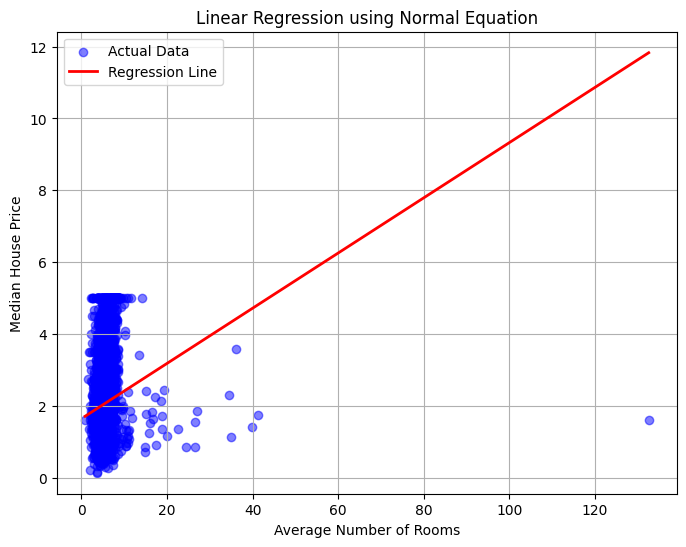

In [14]:
sorted_index = np.argsort(X_test.flatten())

plt.figure(figsize=(8,6))

plt.scatter(
    X_test,
    y_test,
    color='blue',
    alpha=0.5,
    label="Actual Data"
)

plt.plot(
    X_test.flatten()[sorted_index],
    y_pred_ne[sorted_index],
    color='red',
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Average Number of Rooms")
plt.ylabel("Median House Price")
plt.title("Linear Regression using Normal Equation")

plt.legend()

plt.grid(True)

plt.show()

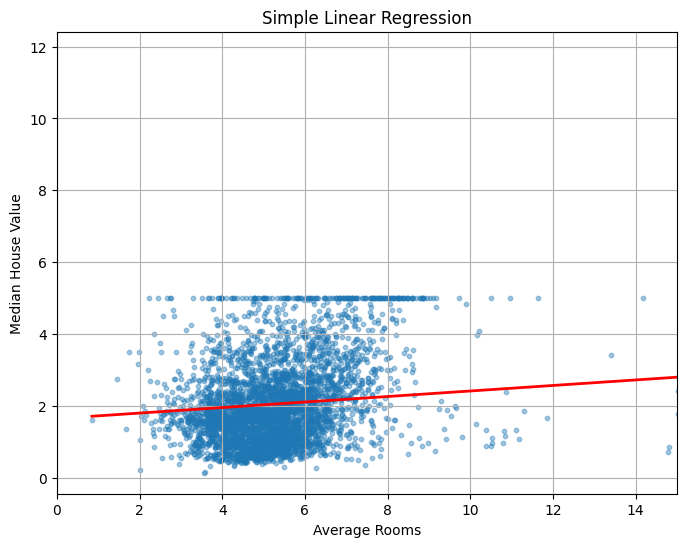

In [18]:
sorted_idx = np.argsort(X_test.flatten())

plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test, alpha=0.4, s=10)

plt.plot(
    X_test.flatten()[sorted_idx],
    y_pred_ne[sorted_idx],
    color="red",
    linewidth=2
)

plt.xlim(0, 15)   # Ignore extreme outliers for visualization
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.title("Simple Linear Regression")
plt.grid(True)

plt.show()

# Conclusion

- Loaded the California Housing dataset.
- Used **Average Number of Rooms (AveRooms)** as the independent variable.
- Implemented Linear Regression using:
  - Gradient Descent
  - Normal Equation
- Evaluated the models using:
  - Mean Squared Error (MSE)
  - R² Score
- Visualized the fitted regression line.

Both methods successfully learned the relationship between the selected feature and housing prices.